# Random Forest Session Revenue Model Using Kaggle API

This notebook downloads the Google Analytics Customer Revenue Prediction dataset directly from Kaggle using the Kaggle API.


Project modeling task: build a session-level Random Forest regression baseline that predicts log-transformed transaction revenue from Google Analytics session features.


In [ ]:
!pip install kaggle -q

## 2. Download the competition dataset

This downloads the Kaggle competition data directly into the Colab runtime.

Important: You may need to join or accept the rules for the Kaggle competition page before the API download will work.


In [ ]:
!kaggle competitions download -c ga-customer-revenue-prediction

ga-customer-revenue-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


## 3. Set dataset path and sample size

Start with `NROWS = 100000` to confirm that the pipeline works. After it runs successfully, increase to `300000` or set `NROWS = None` for the full training file.

The Random Forest model can be slow on the full dataset, so debug on a sample first.


In [ ]:
DATA_PATH = "train_v2.csv"

# Start small. Change to None for the full dataset after debugging.
NROWS = 10000

import os
print("File exists:", os.path.exists(DATA_PATH))
print("Dataset path:", DATA_PATH)

File exists: True
Dataset path: train_v2.csv


## 4. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import json
from pandas import json_normalize

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyRegressor

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 5. Load and flatten JSON columns

The Google Analytics dataset includes nested JSON-style columns. This function expands `device`, `geoNetwork`, `totals`, and `trafficSource` into regular tabular columns.


In [ ]:
JSON_COLUMNS = ["device", "geoNetwork", "totals", "trafficSource"]

def load_ga_data(csv_path, nrows=None):
    """Load Google Analytics data and flatten nested JSON columns."""
    df = pd.read_csv(
        csv_path,
        dtype={"fullVisitorId": "str"},
        converters={col: json.loads for col in JSON_COLUMNS},
        nrows=nrows
    )

    for col in JSON_COLUMNS:
        flattened = json_normalize(df[col])
        flattened.columns = [f"{col}.{subcol}" for subcol in flattened.columns]

        df = df.drop(columns=[col])
        df = pd.concat([df, flattened], axis=1)

    return df

In [ ]:
!unzip ga-customer-revenue-prediction.zip -d .
df = load_ga_data(DATA_PATH, nrows=NROWS)

print("Dataset shape:", df.shape)
df.head()

Archive:  ga-customer-revenue-prediction.zip
replace ./sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## 6. Create session-level target variable

The project abstract defines the prediction target as session-level revenue. Since revenue is highly skewed and many sessions have zero revenue, we use:

`log_revenue = log1p(transactionRevenue)`


In [ ]:
df["totals.transactionRevenue"] = pd.to_numeric(
    df["totals.transactionRevenue"],
    errors="coerce"
).fillna(0)

df["log_revenue"] = np.log1p(df["totals.transactionRevenue"])

print(df["log_revenue"].describe())
print("Share of zero-revenue sessions:", (df["log_revenue"] == 0).mean())

## 7. Create date features

In [ ]:
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

df[["date", "year", "month", "day", "dayofweek", "weekofyear"]].head()

## 8. Convert numeric columns

In [ ]:
numeric_cols = [
    "visitNumber",
    "totals.hits",
    "totals.pageviews",
    "totals.bounces",
    "totals.newVisits",
    "totals.timeOnSite"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df[[col for col in numeric_cols if col in df.columns]].head()

## 9. Select model features

This feature set uses session behavior, date fields, traffic source, device attributes, and geography.


In [ ]:
feature_cols = [
    # session behavior
    "visitNumber",
    "totals.hits",
    "totals.pageviews",
    "totals.bounces",
    "totals.newVisits",
    "totals.timeOnSite",

    # date features
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",

    # traffic source
    "channelGrouping",
    "trafficSource.source",
    "trafficSource.medium",
    "trafficSource.campaign",
    "trafficSource.keyword",
    "trafficSource.referralPath",

    # device
    "device.browser",
    "device.operatingSystem",
    "device.isMobile",
    "device.deviceCategory",

    # geography
    "geoNetwork.continent",
    "geoNetwork.subContinent",
    "geoNetwork.country",
    "geoNetwork.region",
    "geoNetwork.metro",
    "geoNetwork.city"
]

feature_cols = [col for col in feature_cols if col in df.columns]

print("Number of selected features:", len(feature_cols))
print(feature_cols)

model_df = df[feature_cols + ["log_revenue"]].copy()
model_df.head()

## 10. Encode categorical variables and handle missing values

For the Random Forest baseline, categorical features are label encoded. This is simple and fast enough for a baseline, although later models such as LightGBM or XGBoost may handle sparse categorical patterns better.


In [ ]:
for col in model_df.columns:
    if model_df[col].dtype == "object" or model_df[col].dtype == "bool":
        model_df[col] = model_df[col].fillna("missing").astype(str)

        encoder = LabelEncoder()
        model_df[col] = encoder.fit_transform(model_df[col])

model_df = model_df.fillna(0)

print("Modeling dataframe shape:", model_df.shape)
model_df.head()

## 11. Create 80/10/10 train, validation, and test splits

The project abstract specifies an 80/10/10 split. The validation set is used for model comparison. The test set should be used only after the model setup is finalized.


In [ ]:
X = model_df.drop(columns=["log_revenue"])
y = model_df["log_revenue"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

## 12. Baseline mean regressor

This model predicts the mean log revenue from the training set for every validation row. The Random Forest should improve on this baseline.


In [ ]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_val_pred = baseline.predict(X_val)

baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_val_pred))
baseline_mae = mean_absolute_error(y_val, baseline_val_pred)
baseline_r2 = r2_score(y_val, baseline_val_pred)

print("Baseline Model")
print("Validation RMSE:", baseline_rmse)
print("Validation MAE:", baseline_mae)
print("Validation R²:", baseline_r2)

## 13. Train Random Forest Regressor

These settings are conservative to keep runtime manageable. After the notebook works, you can tune `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=10,
                      min_samples_split=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

## 14. Evaluate Random Forest on validation set

In [ ]:
rf_val_pred = rf_model.predict(X_val)

rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)

print("Random Forest Validation Results")
print("Validation RMSE:", rf_val_rmse)
print("Validation MAE:", rf_val_mae)
print("Validation R²:", rf_val_r2)

Random Forest Validation Results
Validation RMSE: 1.5421844264049458
Validation MAE: 0.26673623105184785
Validation R²: 0.25577570531896054


In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline Mean Regressor", "Random Forest Regressor"],
    "Validation RMSE": [baseline_rmse, rf_val_rmse],
    "Validation MAE": [baseline_mae, rf_val_mae],
    "Validation R2": [baseline_r2, rf_val_r2]
})

results

,Model,Validation RMSE,Validation MAE,Validation R2
0,Baseline Mean Regressor,1.787662,0.356346,-0.000005
1,Random Forest Regressor,1.542184,0.266736,0.255776


## 15. Evaluate final Random Forest on test set

Only use this after you are satisfied with the validation results.


In [ ]:
rf_test_pred = rf_model.predict(X_test)

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Test Results")
print("Test RMSE:", rf_test_rmse)
print("Test MAE:", rf_test_mae)
print("Test R²:", rf_test_r2)

Random Forest Test Results
Test RMSE: 1.4158752686094096
Test MAE: 0.24425418134680976
Test R²: 0.3218130656966798


## 16. Feature importance

This supports model interpretability by identifying which web analytics features contribute most to the Random Forest predictions.


In [ ]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
2,totals.pageviews,0.253040
1,totals.hits,0.197918
5,totals.timeOnSite,0.144870
23,geoNetwork.country,0.045585
0,visitNumber,0.042648
8,day,0.032606
16,trafficSource.referralPath,0.031905
10,weekofyear,0.029127
9,dayofweek,0.021250
7,month,0.020976


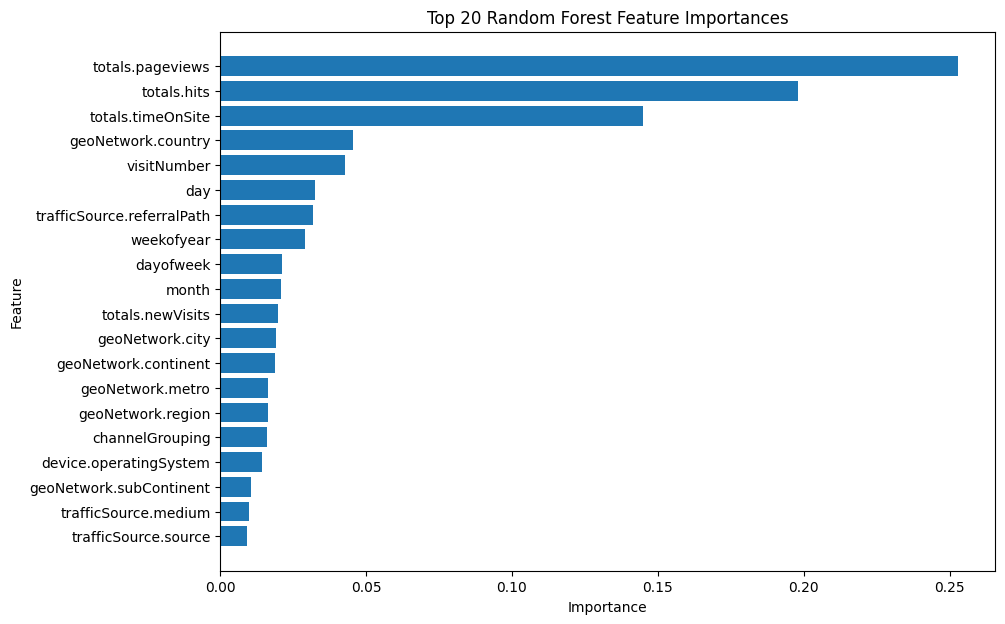

In [ ]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.show()

## 17. Save results

This saves model comparison metrics and feature importance tables as CSV files.


In [ ]:
results.to_csv("random_forest_validation_results.csv", index=False)
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("Saved:")
print("- random_forest_validation_results.csv")
print("- random_forest_feature_importance.csv")

Saved:
- random_forest_validation_results.csv
- random_forest_feature_importance.csv


## 18. Draft report language

Random Forest model description:

> We implemented a Random Forest Regressor as a single-stage baseline model for predicting session-level revenue from Google Analytics web session data. The model uses flattened session-level features from device, geographic, traffic source, temporal, and behavioral fields. The target variable is log-transformed transaction revenue, defined as `log1p(transactionRevenue)`, to reduce the effect of the highly skewed revenue distribution. We used an 80/10/10 train, validation, and test split, consistent with our project plan. Model performance was evaluated using RMSE on log-transformed revenue, with MAE and R² included as secondary metrics. The Random Forest model was compared against a mean-value baseline regressor to determine whether the selected web analytics features improved predictive performance.

Limitations:

> One limitation of the Random Forest model is that the target variable is highly sparse because most sessions generate zero revenue. As a result, the model may perform well on the majority zero-revenue class while still struggling to identify rare high-revenue sessions. In addition, label encoding categorical variables introduces artificial ordinal relationships between categories. Future modeling work should compare this baseline against LightGBM and XGBoost, which are expected to handle sparse, high-dimensional tabular data more effectively.
